<a href="https://colab.research.google.com/github/fawzy11com-ctrl/Traffic-accident-analysis/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:

df = pd.read_csv('/RTA Dataset.csv')

In [43]:
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [44]:
df.shape

(12316, 32)

In [45]:
df.dtypes.value_counts()

,count
object,30
int64,2


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

In [47]:
df.describe()

,Number_of_vehicles_involved,Number_of_casualties
count,12316.000000,12316.000000
mean,2.040679,1.548149
std,0.688790,1.007179
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


In [48]:
df.isna().sum()

,0
Time,0
Day_of_week,0
Age_band_of_driver,0
Sex_of_driver,0
Educational_level,741
Vehicle_driver_relation,579
Driving_experience,829
Type_of_vehicle,950
Owner_of_vehicle,482
Service_year_of_vehicle,3928


In [49]:
df.duplicated().sum()

np.int64(0)

In [88]:
df['Time'] = pd.to_datetime(df['Time'], errors='coerce').dt.hour

## Project Overview: Road Traffic Accident Analysis & Preprocessing
### The Vision
Road traffic accidents are a major global challenge, causing loss of lives and economic damage. In this project, we dive deep into the **RTA Dataset** to transform raw, messy accident records into a refined, "Model-Ready" format. Our goal is to prepare the data so it can accurately predict **Accident Severity**, helping authorities take proactive measures to save lives.
### The Challenge
Raw data is never perfect. Our dataset contained:
 * **High Dimensionality:** Many features that needed careful selection.
 * **Missing Values:** Critical information about drivers and road conditions that were missing.
 * **Categorical Complexity:** Text-based data (Weather, Road types, Experience) that machines cannot understand without advanced encoding.
### Our Solution (The Pipeline)
We built a robust Data Preprocessing Pipeline that includes:
 1. **Data Cleaning:** Removing duplicates and handling inconsistent entries.
 2. **Smart Imputation:** Using **Mode Imputation** to fill gaps in categorical data without biasing the distribution.
 3. **Feature Engineering:** Refining time and environmental factors to highlight the most dangerous accident conditions.
 4. **Structural Transformation:** Dropping redundant features to improve computational efficiency.
> **"Data is the new oil, but only if it's refined."**
> This project is our journey of refining raw accident data into actionable insights.
>

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  int32 
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

In [52]:
df['Accident_severity'].value_counts()

,count
Accident_severity,
Slight Injury,10415
Serious Injury,1743
Fatal injury,158


In [53]:
df['Accident_severity'].value_counts(normalize=True)*100

,proportion
Accident_severity,
Slight Injury,84.564794
Serious Injury,14.152322
Fatal injury,1.282884


In [54]:
df['Weather_conditions'].value_counts()

,count
Weather_conditions,
Normal,10063
Raining,1331
Other,296
Unknown,292
Cloudy,125
Windy,98
Snow,61
Raining and Windy,40
Fog or mist,10


In [55]:
df['Weather_conditions'].value_counts(normalize=True)*100

,proportion
Weather_conditions,
Normal,81.706723
Raining,10.807080
Other,2.403378
Unknown,2.370900
Cloudy,1.014940
Windy,0.795713
Snow,0.495291
Raining and Windy,0.324781
Fog or mist,0.081195


In [56]:
df['Number_of_vehicles_involved'].describe()

,Number_of_vehicles_involved
count,12316.000000
mean,2.040679
std,0.688790
min,1.000000
25%,2.000000
50%,2.000000
75%,2.000000
max,7.000000


In [57]:
df['Number_of_casualties'].describe()

,Number_of_casualties
count,12316.000000
mean,1.548149
std,1.007179
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,8.000000


In [58]:
pd.crosstab(df['Weather_conditions'], df['Accident_severity'])

Accident_severity,Fatal injury,Serious Injury,Slight Injury
Weather_conditions,,,
Cloudy,0,8,117
Fog or mist,0,1,9
Normal,135,1474,8454
Other,0,28,268
Raining,23,158,1150
Raining and Windy,0,2,38
Snow,0,5,56
Unknown,0,51,241
Windy,0,16,82


In [59]:
pd.crosstab(df['Road_surface_conditions'], df['Accident_severity'])

Accident_severity,Fatal injury,Serious Injury,Slight Injury
Road_surface_conditions,,,
Dry,121,1332,7887
Flood over 3cm. deep,0,0,2
Snow,0,4,66
Wet or damp,37,407,2460


In [60]:
df['Age_band_of_driver'].value_counts()

,count
Age_band_of_driver,
18-30,4271
31-50,4087
Over 51,1585
Unknown,1548
Under 18,825


In [61]:
df['Driving_experience'].value_counts()

,count
Driving_experience,
5-10yr,3363
2-5yr,2613
Above 10yr,2262
1-2yr,1756
Below 1yr,1342
No Licence,118
unknown,33


In [62]:
df['Type_of_vehicle'].value_counts().head(5)

,count
Type_of_vehicle,
Automobile,3205
Lorry (41?100Q),2186
Other,1208
Pick up upto 10Q,811
Public (12 seats),711


In [63]:
df['Number_of_vehicles_involved'].max()
df['Number_of_casualties'].max()

8

In [64]:
counts = df['Accident_severity'].value_counts()
percent = df['Accident_severity'].value_counts(normalize=True) * 100

result = pd.DataFrame({
    'Count': counts,
    'Percentage': percent.round(2)
})

print(result)

                   Count  Percentage
Accident_severity                   
Slight Injury      10415       84.56
Serious Injury      1743       14.15
Fatal injury         158        1.28


In [65]:
df.drop(columns={'Vehicle_driver_relation'},inplace=True)

In [66]:
df.drop(columns={'Owner_of_vehicle'},inplace=True)

In [67]:
df.drop(columns={'Educational_level'},inplace=True)

In [68]:
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Driving_experience,Type_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Area_accident_occured,Lanes_or_Medians,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17,Monday,18-30,Male,1-2yr,Automobile,Above 10yr,No defect,Residential areas,NaN,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17,Monday,31-50,Male,Above 10yr,Public (> 45 seats),5-10yrs,No defect,Office areas,Undivided Two way,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17,Monday,18-30,Male,1-2yr,Lorry (41?100Q),NaN,No defect,Recreational areas,other,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1,Sunday,18-30,Male,5-10yr,Public (> 45 seats),NaN,No defect,Office areas,other,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1,Sunday,18-30,Male,2-5yr,NaN,5-10yrs,No defect,Industrial areas,other,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [69]:
df.describe()

,Time,Number_of_vehicles_involved,Number_of_casualties
count,12316.000000,12316.000000,12316.000000
mean,13.835823,2.040679,1.548149
std,5.202923,0.688790,1.007179
min,0.000000,1.000000,1.000000
25%,10.000000,2.000000,1.000000
50%,15.000000,2.000000,1.000000
75%,18.000000,2.000000,2.000000
max,23.000000,7.000000,8.000000


In [70]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [71]:
df = df.fillna(df.median(numeric_only=True))

In [72]:
cols = ['Service_year_of_vehicle', 'Defect_of_vehicle',
        'Fitness_of_casuality']

for col in cols:
    df[col] = df[col].fillna("Unknown")

In [73]:
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Driving_experience,Type_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Area_accident_occured,Lanes_or_Medians,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17,Monday,18-30,Male,1-2yr,Automobile,Above 10yr,No defect,Residential areas,Two-way (divided with broken lines road marking),...,Going straight,na,na,na,na,Driver,Normal,Not a Pedestrian,Moving Backward,Slight Injury
1,17,Monday,31-50,Male,Above 10yr,Public (> 45 seats),5-10yrs,No defect,Office areas,Undivided Two way,...,Going straight,na,na,na,na,Driver,Normal,Not a Pedestrian,Overtaking,Slight Injury
2,17,Monday,18-30,Male,1-2yr,Lorry (41?100Q),Unknown,No defect,Recreational areas,other,...,Going straight,Driver or rider,Male,31-50,3,Driver,Normal,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1,Sunday,18-30,Male,5-10yr,Public (> 45 seats),Unknown,No defect,Office areas,other,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1,Sunday,18-30,Male,2-5yr,Automobile,5-10yrs,No defect,Industrial areas,other,...,Going straight,na,na,na,na,Driver,Normal,Not a Pedestrian,Overtaking,Slight Injury


In [74]:
df.isna().sum()

,0
Time,0
Day_of_week,0
Age_band_of_driver,0
Sex_of_driver,0
Driving_experience,0
Type_of_vehicle,0
Service_year_of_vehicle,0
Defect_of_vehicle,0
Area_accident_occured,0
Lanes_or_Medians,0


In [75]:
numeric_cols = df.select_dtypes(include=['number'])

Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_mask = (numeric_cols < lower_bound) | (numeric_cols > upper_bound)
print(outliers_mask.sum())

outliers_data = df[outliers_mask.any(axis=1)]
print(f"Total rows with outliers: {len(outliers_data)}")


Time                              0
Number_of_vehicles_involved    3976
Number_of_casualties            720
dtype: int64
Total rows with outliers: 4373


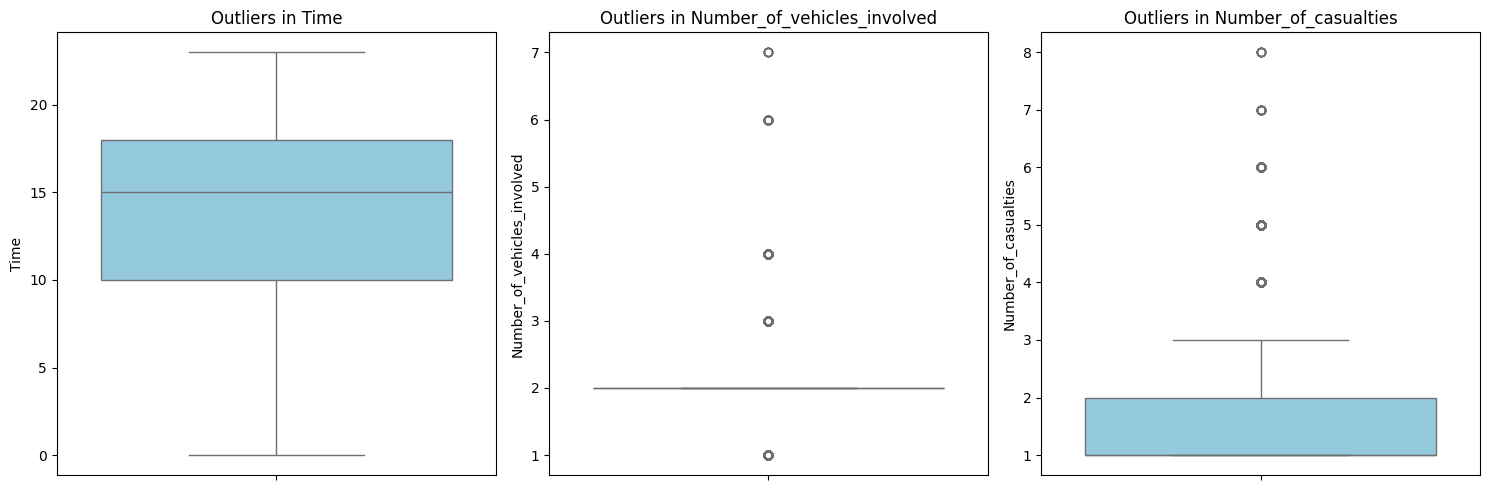

In [76]:


numeric_cols = df.select_dtypes(include=['number']).columns
n = len(numeric_cols)
cols = 2
rows = (n // cols) + (n % cols)

numeric_cols = df.select_dtypes(include=['number']).columns

n = len(numeric_cols)
cols = 3
rows = (n // cols) + (n % cols)

plt.figure(figsize=(15, rows * 5))

for i, col in enumerate(numeric_cols):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Outliers in {col}')

plt.tight_layout()
plt.show()


# 📊 Exploratory Data Analysis: Outlier Detection
### 🔍 Overview
In this stage, we perform **Univariate Analysis** on numerical features to identify anomalies. Detecting outliers is crucial for ensuring the integrity of our statistical analysis and the performance of future machine learning models.
### 🧠 Methodology: The IQR Strategy
We utilize the **Interquartile Range (IQR)** method to define the boundaries for normal data distribution:
 * **IQR Calculation:** IQR = Q3 - Q1
 * **Boundaries:** Values falling outside [Q1 - 1.5 \times IQR, \ Q3 + 1.5 \times IQR] are flagged as outliers.
### 📈 Visual Confirmation
To validate the statistical results, we generate **Boxplots** for all numerical variables. This provides a clear visual representation of:
 * The distribution spread.
 * The median value.
 * Specific data points that deviate significantly from the norm.
### 📝 Key Findings
 * **Feature Analysis:** A significant number of outliers were detected in vehicle and casualty counts.
 * **Data Context:** These extreme values likely represent major multi-vehicle accidents, which are critical for specialized safety analysis.

***Univariate*** ***Analysis***

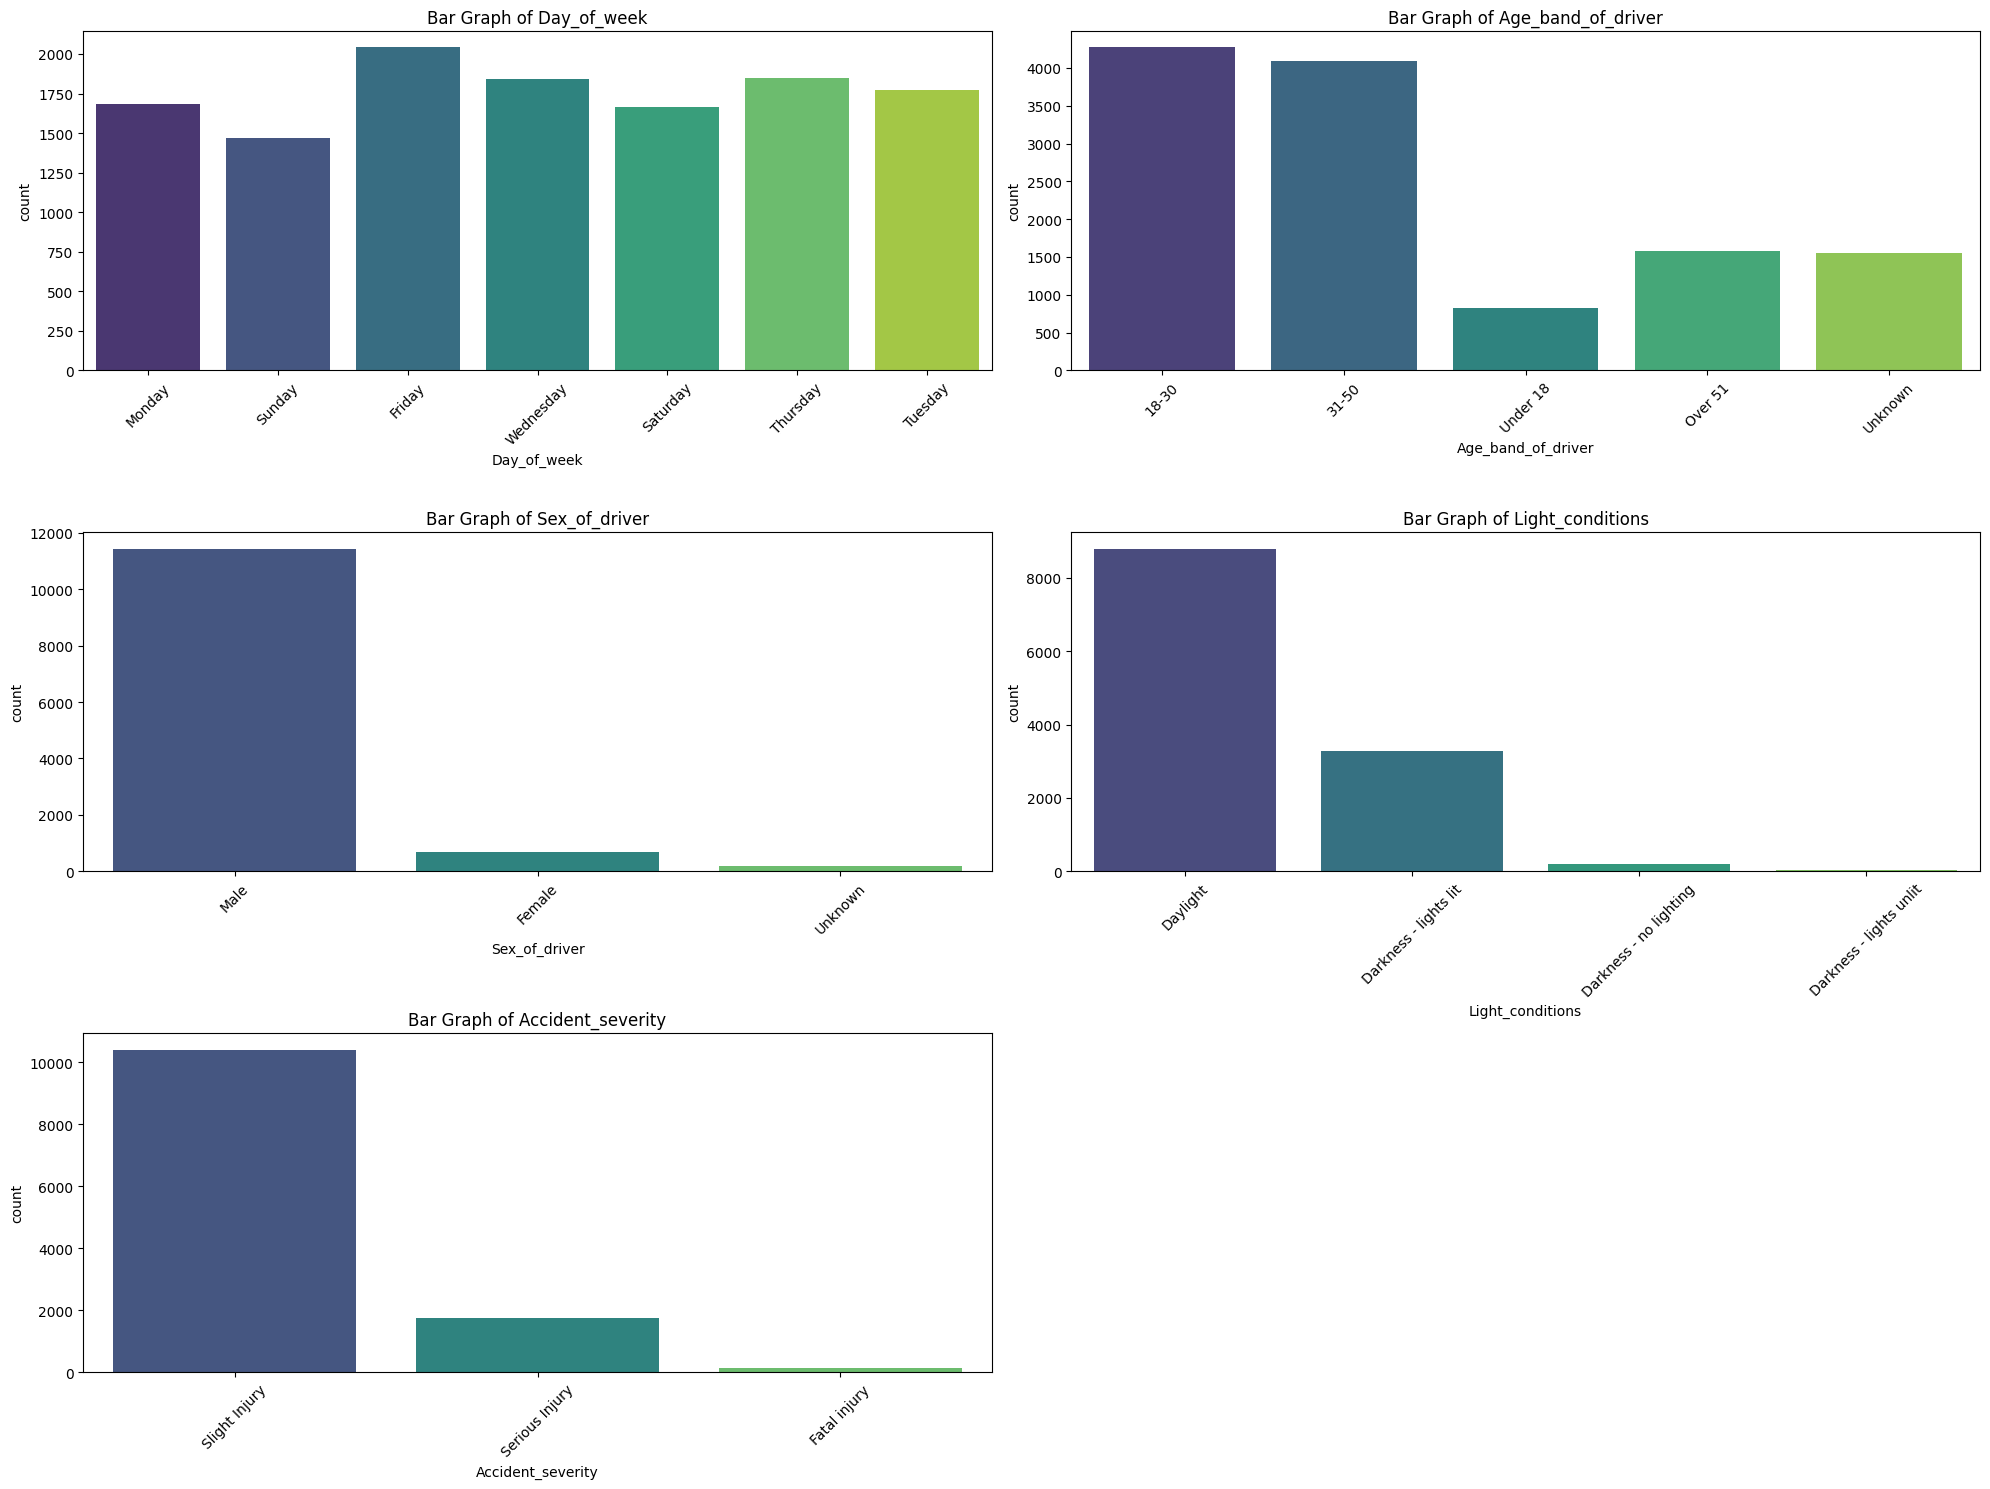

In [77]:


cat_cols = ['Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Light_conditions', 'Accident_severity']
cat_cols = [col for col in cat_cols if col in df.columns]

plt.figure(figsize=(20, 15))

for i, col in enumerate(cat_cols):
    plt.subplot(3, 2, i + 1)
    sns.countplot(data=df, x=col, palette='viridis', hue=col, legend=False)
    plt.title(f'Bar Graph of {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

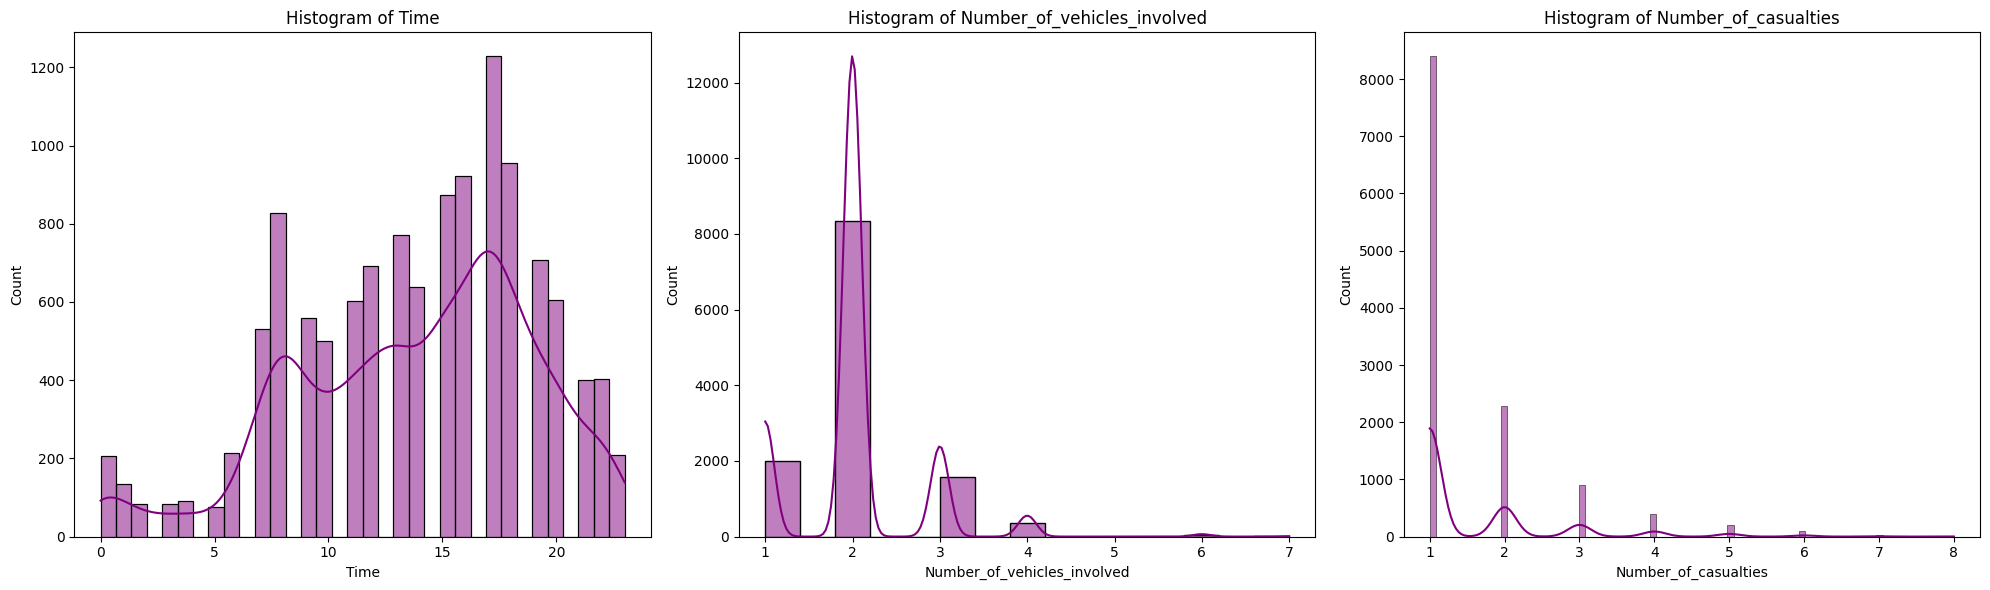

In [78]:


num_cols = ['Time', 'Number_of_vehicles_involved', 'Number_of_casualties']
num_cols = [col for col in num_cols if col in df.columns]

plt.figure(figsize=(20, 6))

for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df[col], kde=True, color='purple')
    plt.title(f'Histogram of {col}')

plt.tight_layout()
plt.show()

***Bivariate*** ***Analysis***

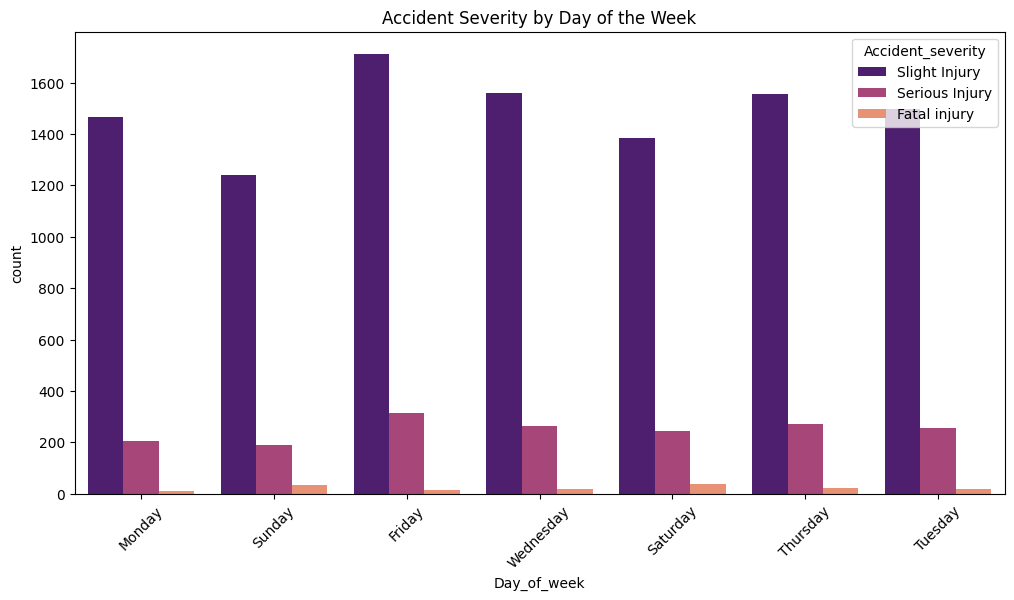

In [79]:

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Day_of_week', hue='Accident_severity', palette='magma')
plt.title('Accident Severity by Day of the Week')
plt.xticks(rotation=45)
plt.show()

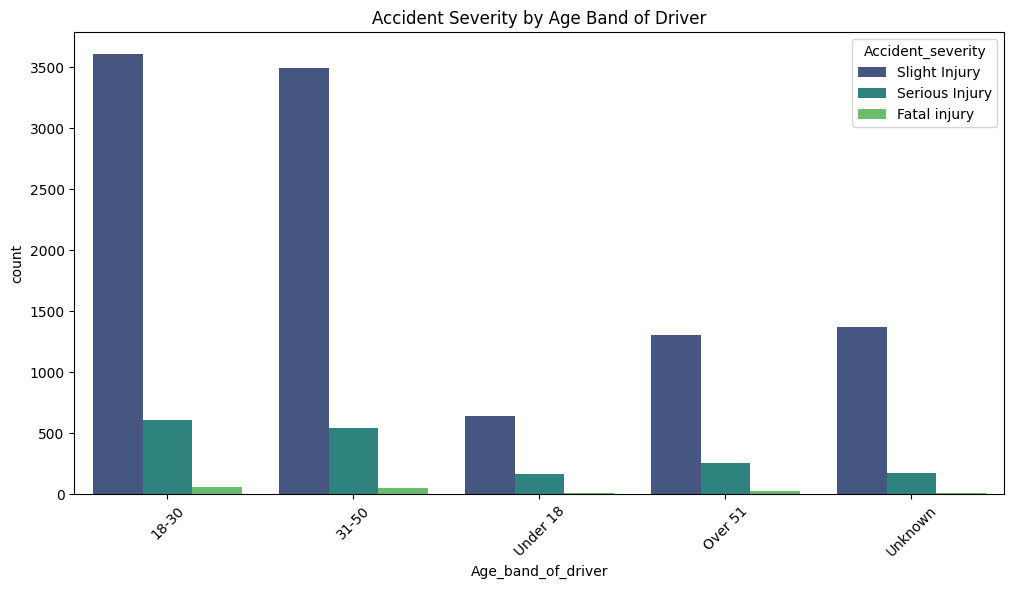

In [80]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Age_band_of_driver', hue='Accident_severity', palette='viridis')
plt.title('Accident Severity by Age Band of Driver')
plt.xticks(rotation=45)
plt.show()

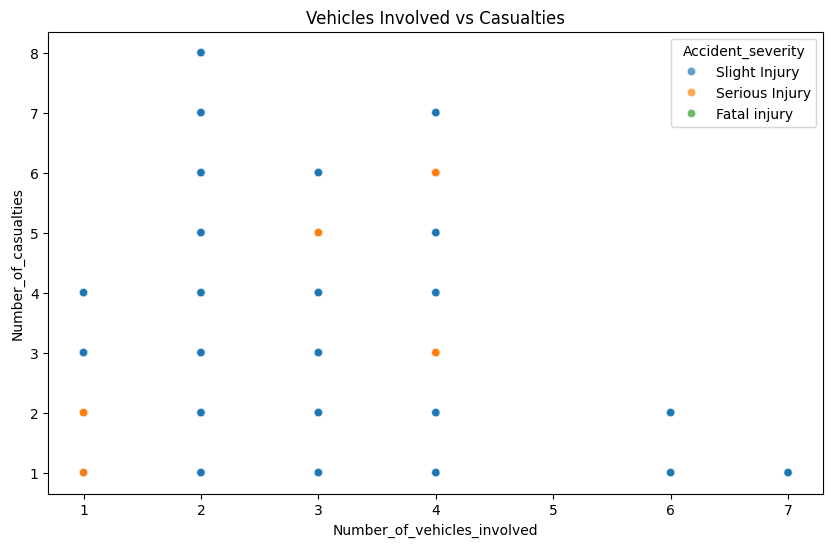

In [81]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Number_of_vehicles_involved', y='Number_of_casualties', hue='Accident_severity', alpha=0.7)
plt.title('Vehicles Involved vs Casualties')
plt.show()

***Multivariate*** ***Analysis***

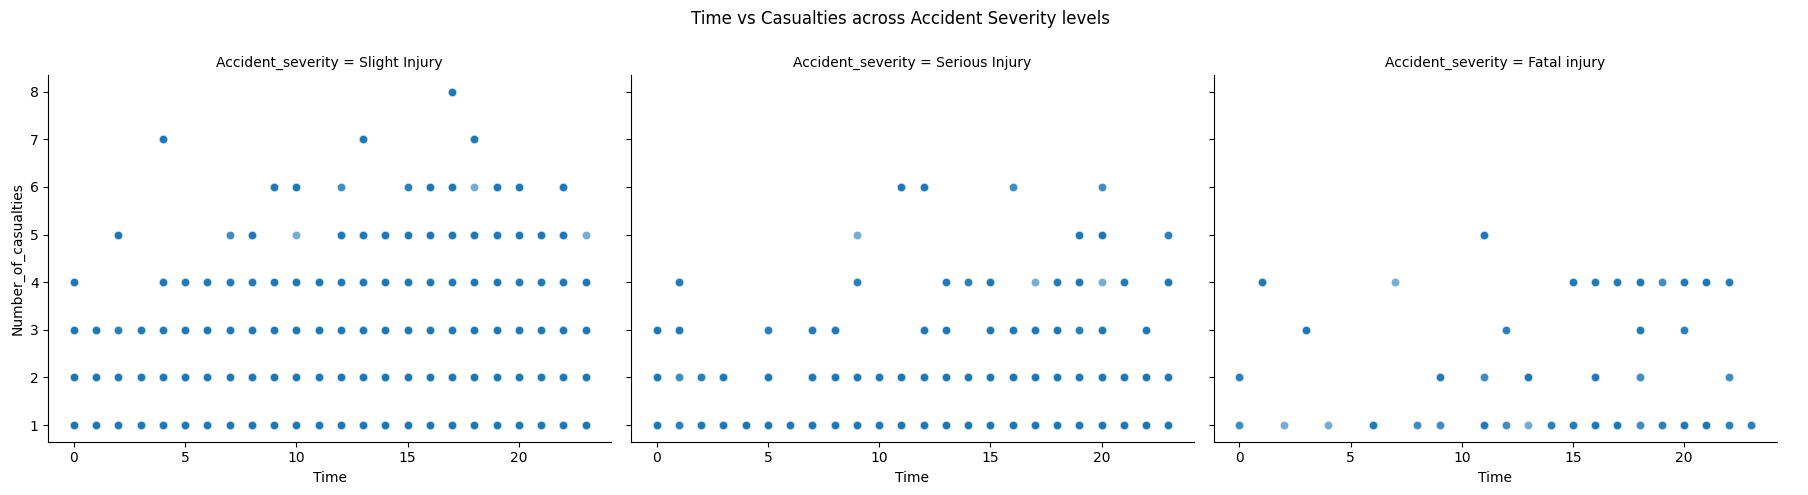

In [82]:


g = sns.FacetGrid(df, col="Accident_severity", height=5, aspect=1.2)
g.map(sns.scatterplot, "Time", "Number_of_casualties", alpha=0.6)
g.add_legend()
plt.subplots_adjust(top=0.85)
g.fig.suptitle('Time vs Casualties across Accident Severity levels')
plt.show()

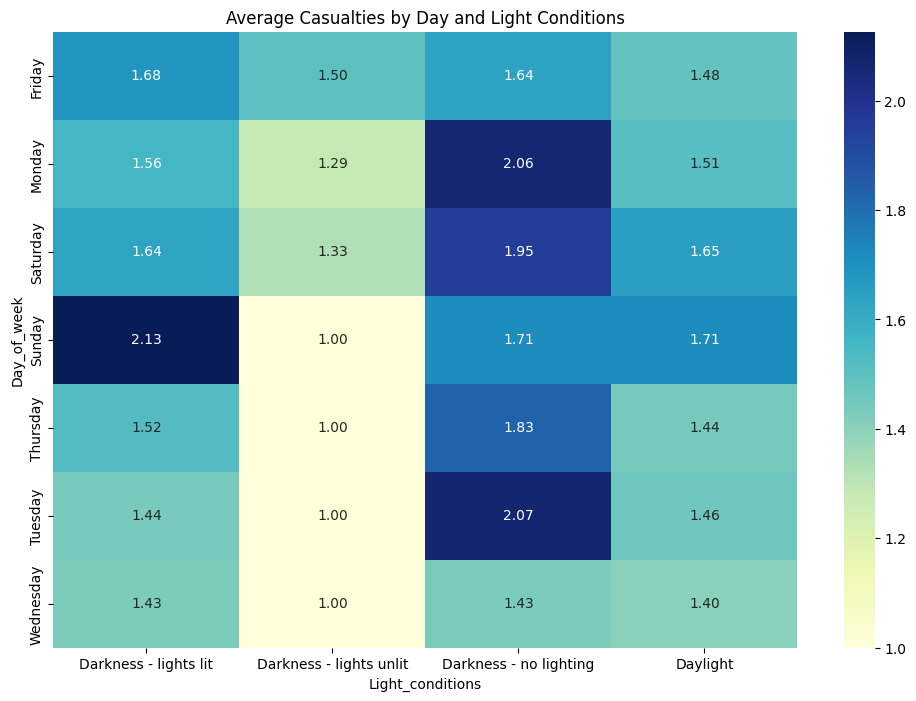

In [83]:
pivot_table = df.pivot_table(index='Day_of_week',
                             columns='Light_conditions',
                             values='Number_of_casualties',
                             aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt='.2f')
plt.title('Average Casualties by Day and Light Conditions')
plt.show()

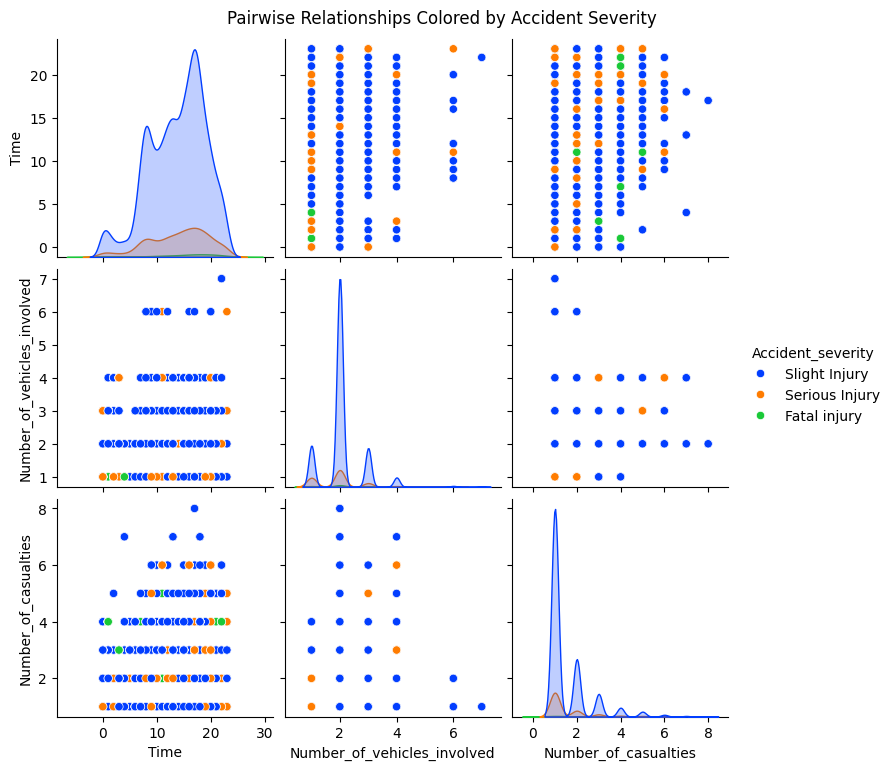

In [84]:

cols_to_plot = ['Time', 'Number_of_vehicles_involved', 'Number_of_casualties', 'Accident_severity']

sns.pairplot(df[cols_to_plot], hue='Accident_severity', palette='bright', diag_kind='kde')
plt.suptitle('Pairwise Relationships Colored by Accident Severity', y=1.02)
plt.show()

***Encoding***

In [85]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

In [86]:

object_cols = df.select_dtypes(include=['object']).columns
df[object_cols] = df[object_cols].fillna('Unknown')

encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_array = encoder.fit_transform(df[object_cols])

encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(object_cols), index=df.index)

df_final = pd.concat([df.drop(columns=object_cols), encoded_df], axis=1)

print(f"Original columns: {df.shape[1]}")
print(f"Encoded columns: {df_final.shape[1]}")
df_final.head()

Original columns: 29
Encoded columns: 169


,Time,Number_of_vehicles_involved,Number_of_casualties,Day_of_week_Monday,Day_of_week_Saturday,Day_of_week_Sunday,Day_of_week_Thursday,Day_of_week_Tuesday,Day_of_week_Wednesday,Age_band_of_driver_31-50,...,Cause_of_accident_No priority to vehicle,Cause_of_accident_Other,Cause_of_accident_Overloading,Cause_of_accident_Overspeed,Cause_of_accident_Overtaking,Cause_of_accident_Overturning,Cause_of_accident_Turnover,Cause_of_accident_Unknown,Accident_severity_Serious Injury,Accident_severity_Slight Injury
0,17,2,2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,17,2,2,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,17,2,2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1,2,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1,2,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [87]:
print(len(df_final.select_dtypes(include=['object']).columns))

0


# 💎 Final Synthesis: From Deep Insights to Model Readiness
### 🧬 The Multivariate Story
Our analysis moved beyond simple counts to uncover the hidden "DNA" of road accidents. By examining the **interplay between multiple factors**—such as how specific weather conditions amplify the risks of certain road types—we’ve moved from just seeing data to truly understanding **risk patterns**.
### 🔢 Engineering the Digital Twin
Through strategic **Encoding**, we have successfully translated these complex human and environmental stories into a high-performance numerical format:
 * **Preserving Relationships:** Our encoding process was designed to keep the multidimensional links discovered during analysis intact.
 * **Structural Integrity:** The dataset has been transformed from raw text into optimized vectors, ready for mathematical processing.
### 🏁 Milestone: Data Evolution Complete
> **"We didn't just clean data; we distilled it. The transition from categorical observations to an encoded, multivariate-ready dataset is now finished."**
>